In [1]:
import torch
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer
import pandas as pd
import numpy as np
#from lingua import LanguageDetectorBuilder, Language
#from sentence_transformers import SentenceTransformer
import tqdm.notebook as tqdm
import tables
import extra

In [2]:
model = AutoModelForSeq2SeqLM.from_pretrained("./models/nllb_teacher").eval()
tokenizer = AutoTokenizer.from_pretrained("./models/nllb_teacher")

In [13]:
paracrawl_df = pd.read_csv('./data/en-ru.txt', sep='\t', header=None, index_col=False, quoting=3)
paracrawl_df.columns = ['source', 'target']

In [14]:
paracrawl_df = paracrawl_df.dropna()

In [15]:
paracrawl_df['source_len'] = paracrawl_df['source'].apply(lambda x: len(tokenizer.encode(x)))
paracrawl_df['target_len'] = paracrawl_df['target'].apply(lambda x: len(tokenizer.encode(x)))

<Axes: >

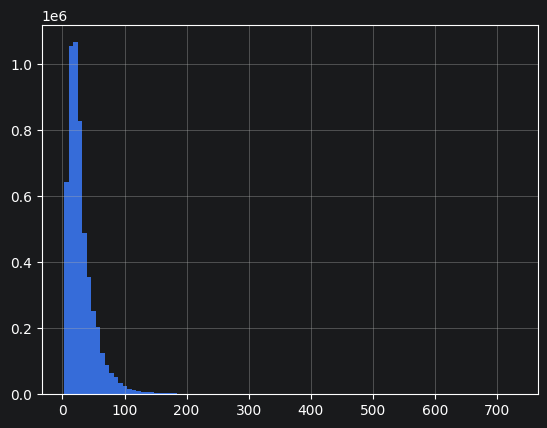

In [16]:
paracrawl_df['source_len'].hist(bins=100)

<Axes: >

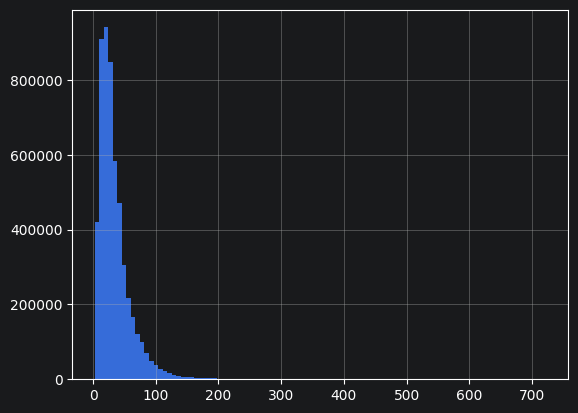

In [17]:
paracrawl_df['target_len'].hist(bins=100)

In [18]:
paracrawl_df['target_len'].describe()

count    5.377899e+06
mean     3.516949e+01
std      2.812119e+01
min      3.000000e+00
25%      1.800000e+01
50%      2.800000e+01
75%      4.400000e+01
max      7.220000e+02
Name: target_len, dtype: float64

In [19]:
paracrawl_df['source_len'].describe()

count    5.377899e+06
mean     3.086471e+01
std      2.535786e+01
min      3.000000e+00
25%      1.500000e+01
50%      2.400000e+01
75%      3.900000e+01
max      7.290000e+02
Name: source_len, dtype: float64

<Axes: >

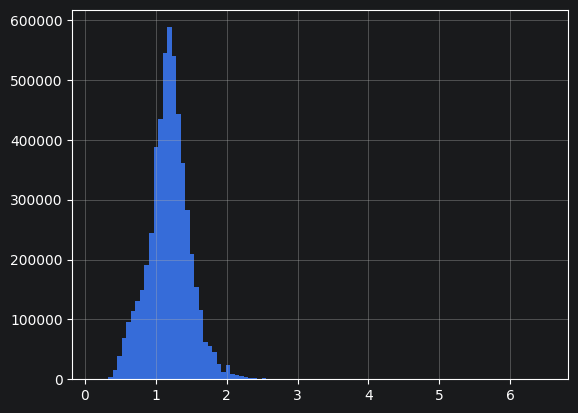

In [20]:
paracrawl_df['len_ratio'] = paracrawl_df['target_len'] / paracrawl_df['source_len']
paracrawl_df['len_ratio'].hist(bins=100)

In [21]:
paracrawl_df['len_ratio'].describe()

count    5.377899e+06
mean     1.190913e+00
std      2.976824e-01
min      1.440678e-01
25%      1.000000e+00
50%      1.190476e+00
75%      1.357143e+00
max      6.500000e+00
Name: len_ratio, dtype: float64

In [22]:
paracrawl_df['target_len'].transform(np.log1p).describe()

count    5.377899e+06
mean     3.368400e+00
std      6.526689e-01
min      1.386294e+00
25%      2.944439e+00
50%      3.367296e+00
75%      3.806662e+00
max      6.583409e+00
Name: target_len, dtype: float64

In [23]:
news_df = pd.read_csv('./data/news-commentary-v18.en-ru.tsv', sep='\t', header=None, index_col=False, quoting=3)
news_df.columns = ['source', 'target']
news_df = news_df.dropna()

In [24]:
news_df.describe()

,source,target
count,377662,377662
unique,376463,376767
top,Why?,Почему?
freq,42,39


In [ ]:
news_df['source_len'] = news_df['source'].apply(lambda x: len(tokenizer.encode(x)))
news_df['target_len'] = news_df['target'].apply(lambda x: len(tokenizer.encode(x)))

In [ ]:
news_df['source_len'].apply(np.log).hist(bins=100)

In [ ]:
news_df['target_len'].hist(bins=100)

In [ ]:
commoncrawl_ru = pd.read_csv('./data/training-parallel-commoncrawl/commoncrawl.ru-en.ru', sep='\t', header=None, index_col=False, quoting=3)
commoncrawl_en = pd.read_csv('./data/training-parallel-commoncrawl/commoncrawl.ru-en.en', sep='\t', header=None, index_col=False, quoting=3)
commoncrawl_df = pd.merge(left=commoncrawl_en, right=commoncrawl_ru, left_index=True, right_index=True, how='inner')
commoncrawl_df.columns = ['source', 'target']

In [ ]:
commoncrawl_df['source_len'] = commoncrawl_df['source'].apply(lambda x: len(tokenizer.encode(x)))
commoncrawl_df['target_len'] = commoncrawl_df['target'].apply(lambda x: len(tokenizer.encode(x)))

In [ ]:
dirty_dataset = pd.concat([commoncrawl_df, news_df, paracrawl_df], ignore_index=True)

In [27]:
dirty_dataset.to_parquet('./data/dirty_dataset.parquet.gzip', compression='gzip')

In [2]:
dirty_dataset = pd.read_parquet('./data/dirty_dataset.parquet.gzip')

In [5]:
dirty_dataset

,source,target,source_len,target_len,len_ratio
0,iron cement is a ready for use paste which is ...,iron cement - это готовая к использованию паст...,42,43,1.023810
1,iron cement protects the ingot against the hot...,После отверждения iron cement защищает кокиль ...,21,25,1.190476
2,iron cement is freshly applied after each stee...,Перед каждой новой заливкой необходимо заново ...,27,28,1.037037
3,"a fire restant repair cement for fire places, ...",огнеупорной ремонтной шпаклевки для топочных у...,22,28,1.272727
4,Translator Internet is a Toolbar for MS Intern...,Language learning can be hard work. You need t...,14,19,1.357143
...,...,...,...,...,...
6633942,Home &gt; Money &amp; Finance &gt; Tips on Red...,Главная &gt; Деньги &amp; финансов &gt; Советы...,30,34,1.133333
6633943,of the ridge the hobbits could see what looked...,хоббиты видели что-то похожее на остатки серо-...,19,26,1.368421
6633944,The Esoteric Philosophy of both these can be b...,Эзотерическая Философия обеих этих религий мож...,54,74,1.370370
6633945,Gh Fragment 176 191 Storage Lyophilized HGH FR...,Хранение 191 части 176 Гх Лиофилизованное ХГХ ...,30,40,1.333333


array([[<Axes: title={'center': 'source_len'}>,
        <Axes: title={'center': 'target_len'}>],
       [<Axes: title={'center': 'len_ratio'}>, <Axes: >]], dtype=object)

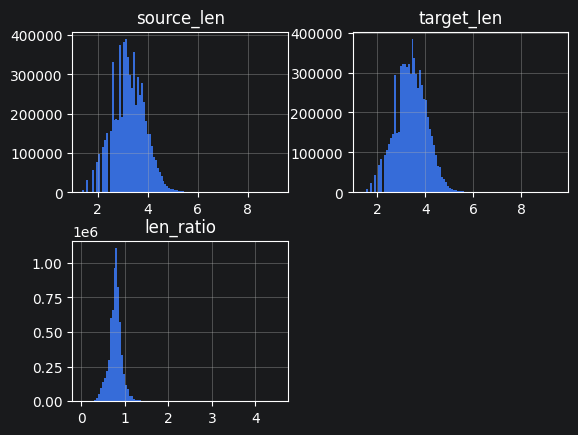

In [6]:
dirty_dataset[['source_len', 'target_len', 'len_ratio']].apply(np.log1p).hist(bins=100)

In [7]:
detector = LanguageDetectorBuilder.from_languages(Language.ENGLISH, Language.RUSSIAN).build()

In [25]:
def get_conf(text, lang):
    return detector.compute_language_confidence(text, lang)

In [26]:
dirty_dataset['source_en_conf'] = dirty_dataset['source'].apply(get_conf, args=(Language.ENGLISH,))
dirty_dataset['target_ru_conf'] = dirty_dataset['target'].apply(get_conf, args=(Language.RUSSIAN,))

In [4]:
cleaner_dataset = dirty_dataset[
    (dirty_dataset['source_en_conf'] > 0.95) &
    (dirty_dataset['target_ru_conf'] > 0.95) &
    (dirty_dataset['len_ratio'] > 0.3) &
    (dirty_dataset['len_ratio'] < 2.0) &
    (dirty_dataset['source_len'] <= 64) &
    (dirty_dataset['source_len'] >= 5) &
    (dirty_dataset['target_len'] <= 64) &
    (dirty_dataset['target_len'] >= 5)
]

In [7]:
encoder = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2", device="cuda")

In [3]:
dataset = pd.read_parquet('./data/cleaner_dataset.parquet.gzip')

In [10]:
scores = np.empty(len(dataset))
for i in tqdm.trange(0, len(dataset), 256):
    source = dataset['source'][i:i + 256].tolist()
    target = dataset['target'][i:i + 256].tolist()

    source_emb = encoder.encode(source, convert_to_numpy=True, normalize_embeddings=True)
    target_emb = encoder.encode(target, convert_to_numpy=True, normalize_embeddings=True)
    scores[i:i + 256] = np.sum(source_emb * target_emb, axis=1)
    del source_emb
    del target_emb

  0%|          | 0/24402 [00:00<?, ?it/s]

In [11]:
dataset['sim_score'] = scores

In [22]:
dataset = dataset[(dataset["source_len"] <= 64) & (dataset["target_len"] <= 64) & (dataset["sim_score"] > 0.75)]

In [23]:
dataset

,source,target,source_len,target_len,len_ratio,source_en_conf,target_ru_conf,sim_score,valid_char_ratio_en,valid_char_ratio_ru
0,iron cement is a ready for use paste which is ...,iron cement - это готовая к использованию паст...,42,43,1.023810,1.0,1.0,0.860285,0.978873,0.979730
1,iron cement protects the ingot against the hot...,После отверждения iron cement защищает кокиль ...,21,25,1.190476,1.0,1.0,0.758205,0.974684,0.988372
2,iron cement is freshly applied after each stee...,Перед каждой новой заливкой необходимо заново ...,27,28,1.037037,1.0,1.0,0.883262,0.937500,0.944444
17,For product or price questions please contact ...,"По вопросам о наличия продукта или цен, пожалу...",14,26,1.857143,1.0,1.0,0.813781,0.984848,0.969388
25,AKVIS Sketch converts digital photos to amazin...,AKVIS Sketch — инструмент для превращения фото...,25,22,0.880000,1.0,1.0,0.888922,0.988636,0.968254
...,...,...,...,...,...,...,...,...,...,...
6633940,The students who successfully complete the PhD...,"Студентам, успешно окончившим аспирантуру, вру...",59,34,0.576271,1.0,1.0,0.791296,0.986159,0.972477
6633941,- While the major events of military history c...,– Пока крупные мероприятия клубов военно-истор...,22,27,1.227273,1.0,1.0,0.825719,0.978947,0.967742
6633942,Home &gt; Money &amp; Finance &gt; Tips on Red...,Главная &gt; Деньги &amp; финансов &gt; Советы...,30,34,1.133333,1.0,1.0,0.761003,0.905882,0.936170
6633945,Gh Fragment 176 191 Storage Lyophilized HGH FR...,Хранение 191 части 176 Гх Лиофилизованное ХГХ ...,30,40,1.333333,1.0,1.0,0.836041,0.869565,0.885496


In [10]:
target_embeddings = encoder.encode(
    smol_dataset['target'].tolist(),
    batch_size=256,
    convert_to_numpy=True,
    normalize_embeddings=True,
    show_progress_bar=True
)
synth_target_embeddings = encoder.encode(
    smol_dataset['synth_target'].tolist(),
    batch_size=256,
    convert_to_numpy=True,
    normalize_embeddings=True,
    show_progress_bar=True
)

Batches:   0%|          | 0/40 [00:00<?, ?it/s]

Batches:   0%|          | 0/40 [00:00<?, ?it/s]

In [11]:
smol_dataset.loc[:, 'synth_sim_score'] = np.sum(target_embeddings * synth_target_embeddings, axis=1)
del target_embeddings
del synth_target_embeddings

/tmp/ipykernel_10866/3158099432.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  smol_dataset.loc[:, 'synth_sim_score'] = np.sum(target_embeddings * synth_target_embeddings, axis=1)


In [24]:
dataset.to_parquet('./data/cleaner_dataset.parquet.gzip', compression='gzip')

In [4]:
dataset = dataset[dataset['sim_score'] > 0.8]

In [8]:
START_TOKEN = tokenizer.convert_tokens_to_ids("rus_Cyrl")

In [5]:
rng = np.random.default_rng()
smol_dataset = dataset.iloc[rng.choice(len(dataset), size=10000, replace=False)]

In [12]:
smol_dataset

,source,target,source_len,target_len,len_ratio,source_en_conf,target_ru_conf,sim_score
6156423,Use the following procedure to configure the s...,"Используйте описанную ниже процедуру, чтобы на...",31,52,1.677419,1.0,1.0,0.763144
3188821,They are also preparing military and technolog...,Готовятся проекты по активизации военно-технич...,27,28,1.037037,1.0,1.0,0.911363
1412476,There are seven piece Wedgwood sets that cost ...,Существует семь кусок Веджвуд устанавливает чт...,16,22,1.375000,1.0,1.0,0.799909
2793289,nice tities indian,красивые индийские чины,6,9,1.500000,1.0,1.0,0.856963
4935288,That in keeping with our existing policy of op...,"Это, в соответствии с нашей существующей полит...",91,124,1.362637,1.0,1.0,0.920423
...,...,...,...,...,...,...,...,...
3769201,Title: Gifts of the Holy Spirit,Название: Дары Святого Духа,11,11,1.000000,1.0,1.0,0.874282
6230456,Christian Louboutin has said that the beauty o...,"Christian Louboutin сказал, чтокрасота девушки...",223,255,1.143498,1.0,1.0,0.940980
5175457,"Sorokina Olga L. – Graduate Student, Departmen...","Сорокина Ольга Леонидовна – магистрант, кафедр...",57,68,1.192982,1.0,1.0,0.891323
5174054,The hotel typology and the physical situation ...,Отель создает напряженный контраст между тради...,42,32,0.761905,1.0,1.0,0.809926


In [9]:
batch_size = 64
synth_targets = np.empty(len(smol_dataset), dtype=object)
for i in tqdm.trange(0, len(smol_dataset), batch_size):
    inputs = tokenizer(smol_dataset['target'][i:i + batch_size].tolist(), return_tensors='pt', padding=True).to(model.device)
    synth_targets[i:i + batch_size] = tokenizer.batch_decode(
        model.generate(**inputs, forced_bos_token_id=START_TOKEN),
        skip_special_tokens=True
    )

smol_dataset.loc[:, 'synth_target'] = synth_targets

  0%|          | 0/157 [00:00<?, ?it/s]

/tmp/ipykernel_10866/513074618.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  smol_dataset.loc[:, 'synth_target'] = synth_targets


In [15]:
smol_dataset[smol_dataset['synth_sim_score'] < 0.5]

,source,target,source_len,target_len,len_ratio,source_en_conf,target_ru_conf,sim_score,synth_target,synth_sim_score
1513981,"CNC milling, cnc machining, cnc drilling, cnc ...","CNC филируя, cnc подвергая механической обрабо...",40,63,1.575000,1.0,1.0,0.857100,"СНК, сверлитель, сверлитель, сверлитель, сверл...",0.321009
5556983,download Your favorite tunes,cкачиваете любимые мелодии,7,12,1.714286,1.0,1.0,0.795265,- Я не знаю.,0.194396
4863035,♥♥♥♥♥♥♥♥♥♥crazy and honest friends♥♥♥♥♥♥♥♥♥,♥♥♥♥♥♥♥♥♥♥сумасшедший и честных друзей♥♥♥♥♥♥♥♥♥,26,30,1.153846,1.0,1.0,0.963807,Я не могу быть с тобой.,0.227935
5619194,Spouse;,Супруг;,5,6,1.200000,1.0,1.0,0.902570,Мужчина.,0.487608
3768067,Publish What You Pay | Rwanda Archives - Publi...,"Публикуй, что платишь | Руанда Archives - Публ...",14,24,1.714286,1.0,1.0,0.946798,"Публикуй, что ты платишь.",0.496928
4252182,The following is a suggested presentation of t...,Нижеследующее — предлагаемый нами вариант преп...,45,75,1.666667,1.0,1.0,0.823783,"Следующий вариант, который мы предлагаем, осно...",0.391962
1151361,What’s at Stake in Libya?,Ливия: что поставлено на карту?,11,12,1.090909,1.0,1.0,0.792382,Что поставлено на карту?,0.489486
3138764,"650/65R38 |NIRA complex – tires, service, rest...","650/65R38 |НИРА комплекса – шины, обслуживание...",26,29,1.115385,1.0,1.0,0.838822,650/65R38 ∙ ∙ ∙ ∙ ∙ ∙ ∙ ∙ ∙ ∙ ∙ ∙ ∙ ∙ ∙ ∙ ∙ ∙ ...,0.231474
5585487,You are here: Home | Golf Putting Green and Dr...,Вы здесь: Главная | Тренажер для гольфа и вожд...,21,24,1.142857,1.0,1.0,0.776340,Вы здесь: Главная │ │ │ │ │ │ │ │ │ │ │ │ │ │ ...,0.471667


In [20]:
def valid_char_percent(text: str):
    return sum(int(ch.isalpha() or ch.isspace()) for ch in text) / len(text)

In [23]:
dataset['valid_char_ratio_en'] = dataset['source'].apply(valid_char_percent)
dataset['valid_char_ratio_ru'] = dataset['target'].apply(valid_char_percent)

In [5]:
filters = tables.Filters(3, "blosc:lz4")
with tables.open_file("./data/tokenized_dataset.hdf5", "w") as file:
    source_ids = file.create_carray(file.root, "source_ids", tables.Int32Atom(), shape=(len(dataset), 64), filters=filters)
    target_ids = file.create_carray(file.root, "target_ids", tables.Int32Atom(), shape=(len(dataset), 64), filters=filters)
    source_mask = file.create_carray(file.root, "source_mask", tables.Int32Atom(), shape=(len(dataset), 64), filters=filters)
    target_mask = file.create_carray(file.root, "target_mask", tables.Int32Atom(), shape=(len(dataset), 64), filters=filters)

    for i in tqdm.trange(0, len(dataset), 256):
        tokenizer.src_lang = "eng_Latn"
        source_tokenized = tokenizer(dataset['source'][i:i + 256].tolist(), padding="max_length", truncation=True, max_length=64)
        tokenizer.src_lang = "rus_Cyrl"
        target_tokenized = tokenizer(dataset['target'][i:i + 256].tolist(), padding="max_length", truncation=True, max_length=64)

        source_ids[i:i + 256] = source_tokenized["input_ids"]
        target_ids[i:i + 256] = target_tokenized["input_ids"]
        source_mask[i:i + 256] = source_tokenized["attention_mask"]
        target_mask[i:i + 256] = target_tokenized["attention_mask"]

        del source_tokenized
        del target_tokenized

  0%|          | 0/12087 [00:00<?, ?it/s]

In [ ]:
filters = tables.Filters(3, "blosc:lz4")
with tables.open_file("./data/tokenized_dataset_prepped.hdf5", "r") as df, tables.open_file("./data/train_dataset.hdf5", "w") as tf, tables.open_file("./data/val_dataset.hdf5", "w") as vf:
    rng = np.random.default_rng()
    val_len = int(df.root.source_ids.shape[0] * 0.1)
    val_idx = rng.choice(np.arange(df.root.source_ids.shape[0]), size=(val_len,)

In [1]:
import numpy as np
import tables as tb


def split_multi_hdf5(
    input_path: str,
    train_path: str,
    val_path: str,
    *,
    dataset_paths: list[str],
    val_size: float = 0.2,
    seed: int = 42,
    batch_size: int = 10_000,
):
    rng = np.random.default_rng(seed)

    with tb.open_file(input_path, mode="r") as src:
        first = src.get_node(dataset_paths[0])
        n = first.shape[0]

        indices = np.arange(n)
        rng.shuffle(indices)

        val_count = int(n * val_size)

        val_mask = np.zeros(n, dtype=bool)
        val_mask[indices[:val_count]] = True

        train_mask = ~val_mask

        _write_multi_split_sequential(
            src=src,
            output_path=train_path,
            dataset_paths=dataset_paths,
            split_mask=train_mask,
            batch_size=batch_size,
        )

        _write_multi_split_sequential(
            src=src,
            output_path=val_path,
            dataset_paths=dataset_paths,
            split_mask=val_mask,
            batch_size=batch_size,
        )


def _write_multi_split_sequential(
    src: tb.File,
    output_path: str,
    dataset_paths: list[str],
    split_mask: np.ndarray,
    batch_size: int,
):
    filters = tb.Filters(3, "blosc:lz4")

    with tb.open_file(output_path, mode="w") as dst:
        outputs = {}

        for path in dataset_paths:
            source = src.get_node(path)

            if source.shape[0] != len(split_mask):
                raise ValueError(
                    f"Dataset {path} has different first dimension: "
                    f"{source.shape[0]} != {len(split_mask)}"
                )

            group_path, name = path.rsplit("/", 1)

            if group_path == "":
                where = "/"
            else:
                where = dst.create_group(
                    "/",
                    group_path.strip("/"),
                    createparents=True,
                )

            outputs[path] = dst.create_earray(
                where=where,
                name=name,
                atom=tb.Atom.from_dtype(source.dtype),
                shape=(0, *source.shape[1:]),
                filters=filters,
            )

        n = len(split_mask)

        for start in range(0, n, batch_size):
            end = min(start + batch_size, n)

            local_mask = split_mask[start:end]

            if not local_mask.any():
                continue

            for path in dataset_paths:
                source = src.get_node(path)

                # Здесь обычный slice для PyTables
                chunk = source[start:end]

                # А здесь уже numpy indexing
                selected = chunk[local_mask]

                outputs[path].append(selected)


split_multi_hdf5(
    input_path="./data/tokenized_dataset_prepped.hdf5",
    train_path="./data/train_dataset.hdf5",
    val_path="./data/val_dataset.hdf5",
    dataset_paths=[
        "/source_ids",
        "/source_mask",
        "/target_ids",
        "/target_mask",
        "/synth_ids",
        "/synth_mask",
        "/teacher_top32_ids",
        "/teacher_top32_logits",
        "/teacher_top32_token_ids"
    ],
    val_size=0.1,
    batch_size=10000
)